In [1]:
import numpy as np
import math 
import matplotlib.pyplot as plt
import csv
from csv import writer
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator

In [35]:
#filename='lakeshore_log_2025-01-01T18-41-11'
#filename1='temperature_log_2025-01-01T18-41-11'
#filename2='lakeshore_log_2025-01-25T17-26-16'
#filename3='temperature_log_2025-01-25T17-26-16'
filename2='lakeshore/lakeshore_log_2025-04-13T04-50-05'
filename3='cryo_cooler/temperature_log_2025-04-13T04-50-05'

In [100]:
# Lakeshore
#data_temp=np.loadtxt(filename2+".txt", usecols=1, skiprows=0, dtype='str',delimiter=",") 
data_temp_1 = np.loadtxt(filename2+".txt", usecols=1, skiprows=0, dtype='str',delimiter=",") 
data_temp_2 = np.loadtxt(filename2+".txt", usecols=2, skiprows=0, dtype='str',delimiter=",") 
data_temp_3 = np.loadtxt(filename2+".txt", usecols=3, skiprows=0, dtype='str',delimiter=",")
#data_date =  np.loadtxt(filename2+".txt", usecols=0, skiprows=0, dtype='str') 
data_time1 =  np.loadtxt(filename2+".txt", usecols=0, skiprows=0, dtype='str',delimiter=",") 

In [112]:
data_temp1=np.zeros(len(data_temp_1))
for i in range(len(data_temp_1)):
    data_temp1[i]=float(data_temp_1[i][2:])

data_temp2=np.zeros(len(data_temp_2))
for i in range(len(data_temp_2)):
    data_temp2[i]=float(data_temp_2[i][1:])

data_temp3=np.zeros(len(data_temp_3))
for i in range(len(data_temp_3)):
    data_temp3[i]=float(data_temp_3[i][1:])

In [113]:
data_temp2

array([301.05, 301.05, 301.  , ..., 279.88, 279.92, 279.92])

In [33]:
data_time=np.empty(len(data_time1),dtype='U10')
for i in range(len(data_time1)):
    data_time[i]=data_time1[i].split(' ')[1]

In [140]:
data_time_coarse=np.empty(len(data_time1),dtype='U10')

j=0
for i in range(len(data_time)):
    if i%4==0:
        data_time_coarse[j]=data_time[i]
        j+=1

data_time_coarse = np.array([i for i in data_time_coarse if i])

data_temp1_coarse=np.zeros(len(data_time_coarse))
data_temp2_coarse=np.zeros(len(data_time_coarse))
data_temp3_coarse=np.zeros(len(data_time_coarse))

j=0
for i in range(len(data_temp_1)):
    if i%4==0:
        data_temp1_coarse[j]=data_temp1[i]
        data_temp2_coarse[j]=data_temp2[i]
        data_temp3_coarse[j]=data_temp3[i]
        j+=1

data_temp1_coarse = np.array([i for i in data_temp1_coarse if i])
data_temp2_coarse = np.array([i for i in data_temp2_coarse if i])
#data_temp3_coarse = np.array([i for i in data_temp3_coarse if i])

In [141]:
len(data_temp3_coarse)

3395

In [63]:
# Cryo cooler
data_temp_cryo1 = np.loadtxt(filename3+".txt", usecols=1, skiprows=0, dtype='str',delimiter=",") 
data_timestamp_cryo1 = np.loadtxt(filename3+".txt", usecols=1, skiprows=0, dtype='str') 
data_date_cryo =  np.loadtxt(filename3+".txt", usecols=0, skiprows=0, dtype='str') 



In [64]:
data_temp_cryo1

array([' [300.86] K', ' [300.57] K', ' [300.17] K', ..., ' [279.76] K',
       ' [279.79] K', ' [279.82] K'], dtype='<U11')

In [126]:
data_temp_cryo=np.zeros(len(data_temp_cryo1))
for i in range(len(data_temp_cryo1)):
    if len(data_temp_cryo1[i])==11:
        data_temp_cryo[i]=float(data_temp_cryo1[i][2:8])
    if len(data_temp_cryo1[i])==10:
        data_temp_cryo[i]=float(data_temp_cryo1[i][2:7])
    if len(data_temp_cryo1[i])==9:
        data_temp_cryo[i]=float(data_temp_cryo1[i][2:6])
    if len(data_temp_cryo1[i])==8:
        data_temp_cryo[i]=float(data_temp_cryo1[i][2:5])
    if len(data_temp_cryo1[i])==7:
        data_temp_cryo[i]=float(data_temp_cryo1[i][2:4])

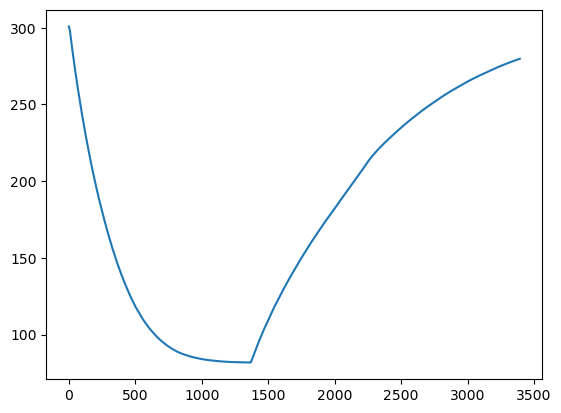

In [127]:
plt.plot(data_temp_cryo)

In [61]:
data_timestamp_cryo=np.copy(data_timestamp_cryo1)
for i in range(len(data_timestamp_cryo1)):
    data_timestamp_cryo[i]=data_timestamp_cryo1[i][:-1]

In [122]:
# time_stamps_cryo=np.empty(len(data_timestamp_cryo), dtype = 'S20')
# for j in range(len(data_timestamp_cryo)):
#     count=-1
#     for i in data_timestamp_cryo[j]:
#         count+=1
#         if i==',':
#             #print(count)
#             time_stamps_cryo[j]=data_timestamp_cryo[j][:count]
        
# #data_timestamp[0]

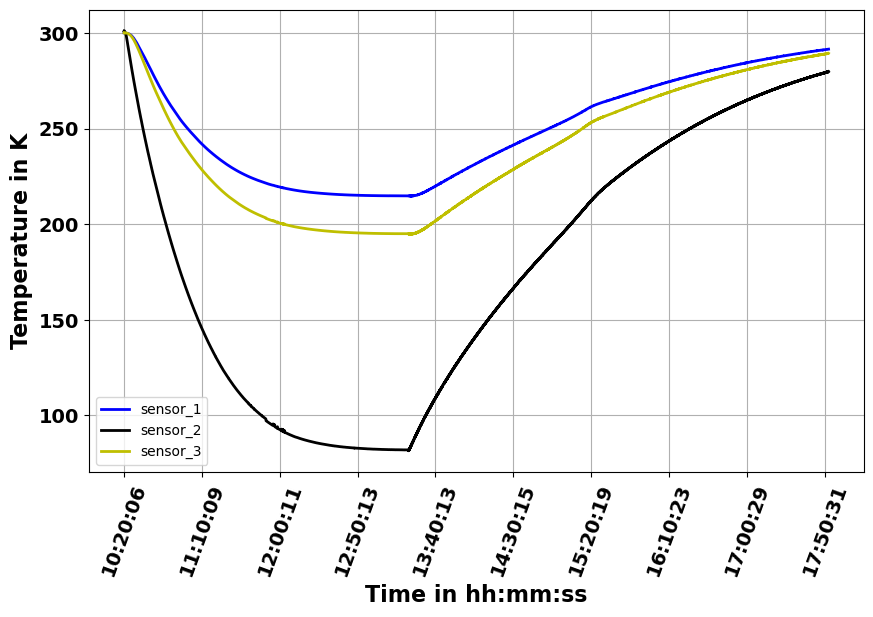

In [117]:
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(data_time,data_temp1,'b-',linewidth=2,label='sensor_1')
plt.plot(data_time,data_temp2,'k-',linewidth=2,label='sensor_2')
plt.plot(data_time,data_temp3,'y-',linewidth=2,label='sensor_3')
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
#plt.title("Lakeshore temperature curve 8 feb 2025 run",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

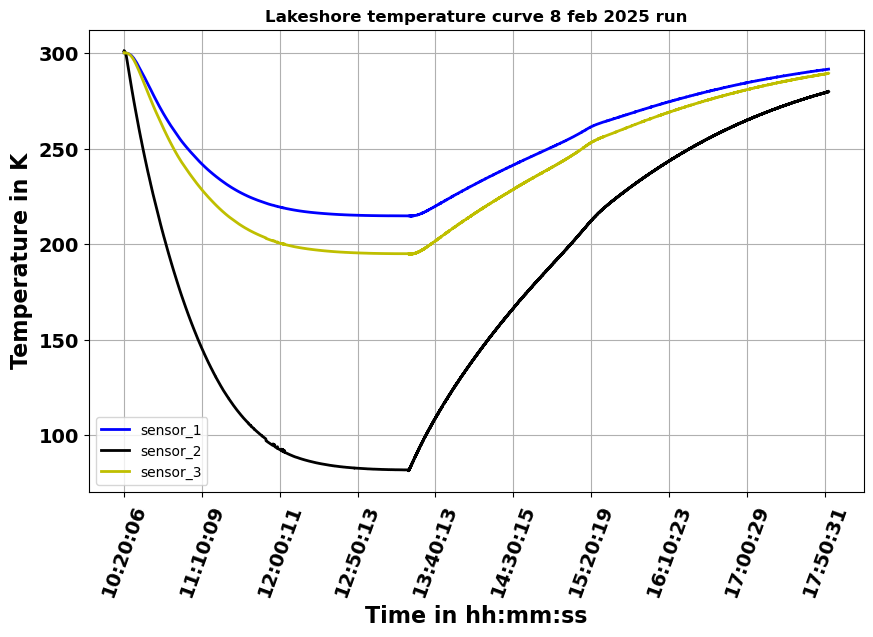

In [129]:
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(data_time,data_temp1,'b-',linewidth=2,label='sensor_1')
plt.plot(data_time,data_temp2,'k-',linewidth=2,label='sensor_2')
plt.plot(data_time,data_temp3,'y-',linewidth=2,label='sensor_3')
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
plt.title("Lakeshore temperature curve 8 feb 2025 run",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

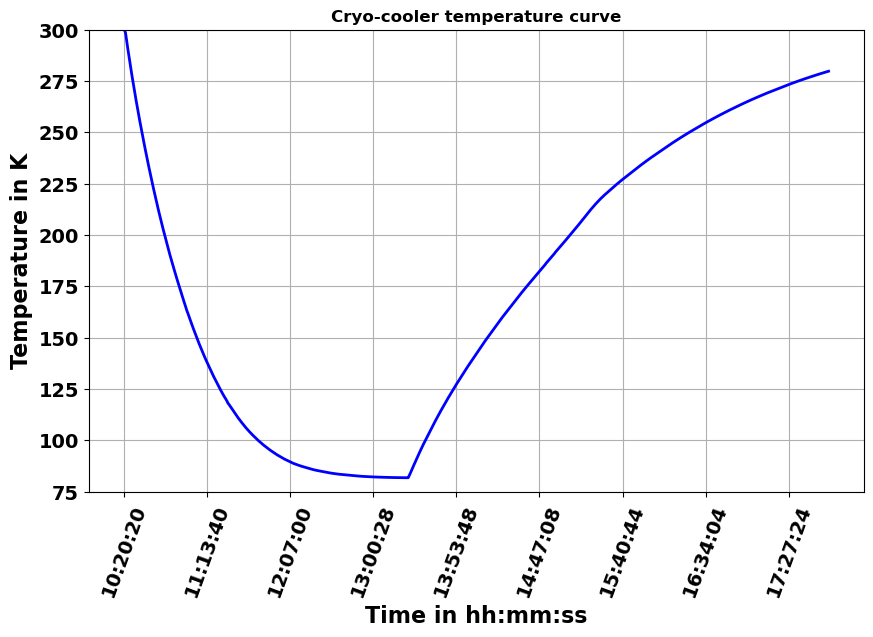

In [128]:
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(data_timestamp_cryo,data_temp_cryo,'b-',linewidth=2)
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
plt.title("Cryo-cooler temperature curve",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.ylim(75,300)
plt.grid()
plt.show()

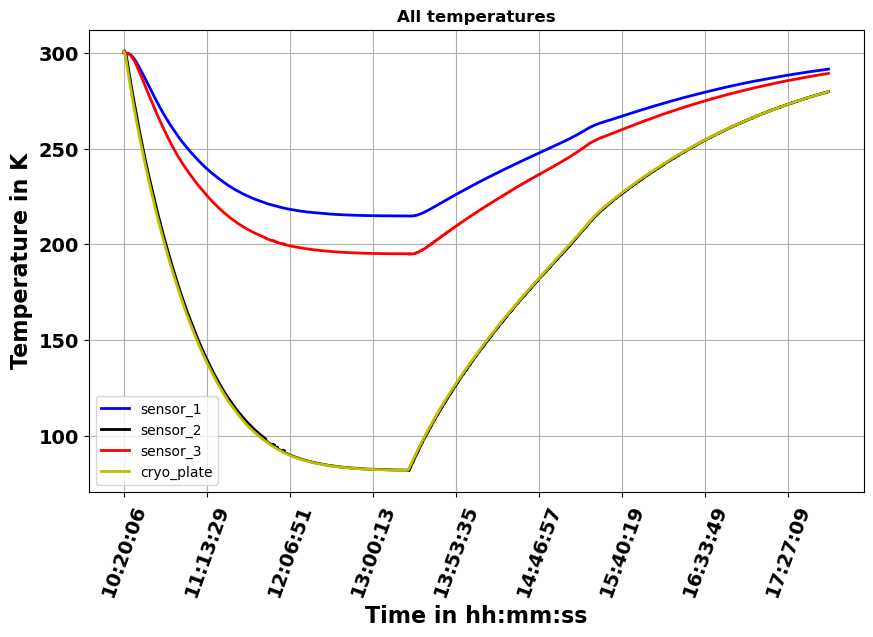

In [143]:
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(data_time_coarse,data_temp1_coarse,'b-',linewidth=2,label='sensor_1')
plt.plot(data_time_coarse,data_temp2_coarse,'k-',linewidth=2,label='sensor_2')
plt.plot(data_time_coarse,data_temp3_coarse,'r-',linewidth=2,label='sensor_3')
plt.plot(data_temp_cryo,'y-',linewidth=2,label='cryo_plate')
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
plt.title("All temperatures",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

In [145]:
# %matplotlib inline 
# #%matplotlib qt 
# fig,ax=plt.subplots(figsize=(10,6))
# plt.plot(data_time_coarse,data_temp1_coarse-data_temp3_coarse,'b-',linewidth=2,label='sensor_1')
# #plt.plot(data_time_coarse[:1000],data_temp2_coarse[:1000],'k-',linewidth=2,label='sensor_2')
# #plt.plot(data_time_coarse[:1000],data_temp3_coarse[:1000],'r-',linewidth=2,label='sensor_3')
# #plt.plot(data_temp_cryo[:1000],'y-',linewidth=2,label='cryo_plate')
# ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
# plt.xticks(rotation=70)
# plt.title("Lakeshore temperature curve 7-feb 2025 run",fontsize='large', fontweight='bold')#- 13/09/24")
# plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
# plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
# plt.xticks(fontsize = 14, fontweight='bold')
# plt.yticks(fontsize = 14, fontweight='bold')
# plt.grid()
# plt.legend()
# plt.show()

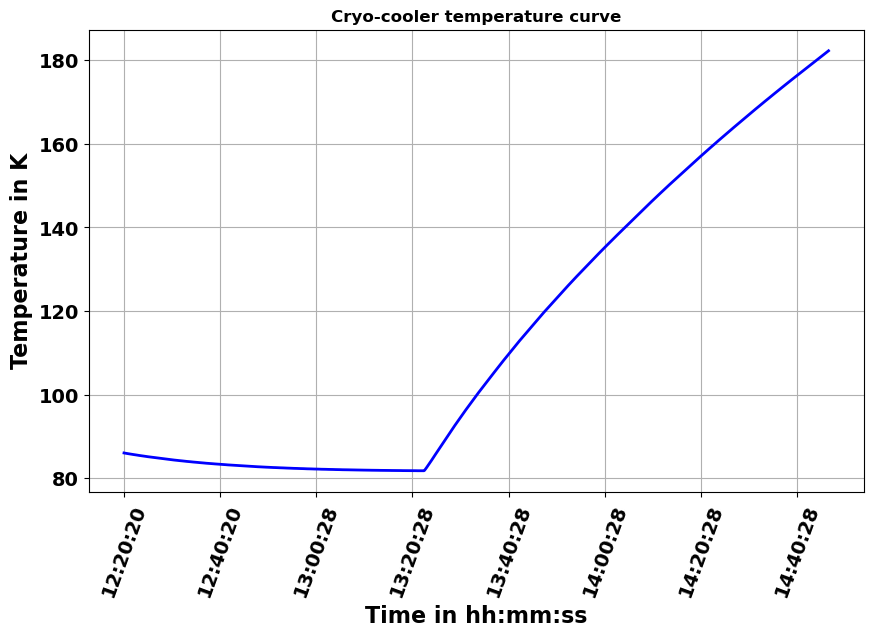

In [147]:
start_cry=900
stop_cry=2000
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(data_timestamp_cryo[start_cry:stop_cry],data_temp_cryo[start_cry:stop_cry],'b-',linewidth=2)
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
plt.title("Cryo-cooler temperature curve",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')

plt.grid()
plt.show()